Import des librairies et de la base de données

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [66]:
df = pd.read_csv(r"C:\Users\utilisateur\Downloads\wetransfer_histo_gazpar_merged-3-csv-gz_2026-01-30_1023\histo_gazpar_merged(1).csv.gz")


Préparation des variables : "trend", "hdd_workday", "hdd_weekend".

In [67]:
# Chargement et conversion des dates
df['date_parsed'] = pd.to_datetime(df['date_parsed'])
df = df.sort_values(['pce', 'date_parsed'])

# Création de la variable 'trend' (tendance temporelle)
df['trend'] = (df['date_parsed'] - df['date_parsed'].min()).dt.days

# Identification des variables de calendrier [cite: 42, 66]
df['is_weekend'] = df['date_parsed'].dt.dayofweek.isin([5, 6]).astype(int)

# Calcul des interactions HDD x Calendrier [cite: 66, 67]
df['hdd_workday'] = df['hdd'] * (1 - df['is_weekend'])
df['hdd_weekend'] = df['hdd'] * df['is_weekend']

Ajout de la colonne : "Is_Public_Holiday"

In [68]:
import pandas as pd

# 1. Chargement du fichier
path_vacances = r"C:\Users\utilisateur\Desktop\programmation\Statap\data\data.csv"
df_vacances = pd.read_csv(path_vacances)

# 2. Créer l'indicateur (1 si vacances dans n'importe quelle zone, 0 sinon)
df_vacances['is_school_holiday'] = (
    df_vacances['vacances_zone_a'] | 
    df_vacances['vacances_zone_b'] | 
    df_vacances['vacances_zone_c']
).astype(int)

# 1. On s'assure que les dates sont au même format (YYYY-MM-DD) sans timezone
df_vacances['date'] = pd.to_datetime(df_vacances['date']).dt.tz_localize(None).dt.strftime('%Y-%m-%d')

# 2. On crée un dictionnaire de correspondance : {date: indicateur}
mapping_vacances = dict(zip(df_vacances['date'], df_vacances['is_school_holiday']))

# 3. On applique ce dictionnaire à ton df principal
# (On transforme la date du df en string pour qu'elle corresponde aux clés du dictionnaire)
df['is_school_holiday'] = (
    pd.to_datetime(df['date_parsed'])
    .dt.tz_localize(None)
    .dt.strftime('%Y-%m-%d')
    .map(mapping_vacances)
    .fillna(0)  # Si une date n'est pas dans le fichier, on met 0
    .astype(int)
)

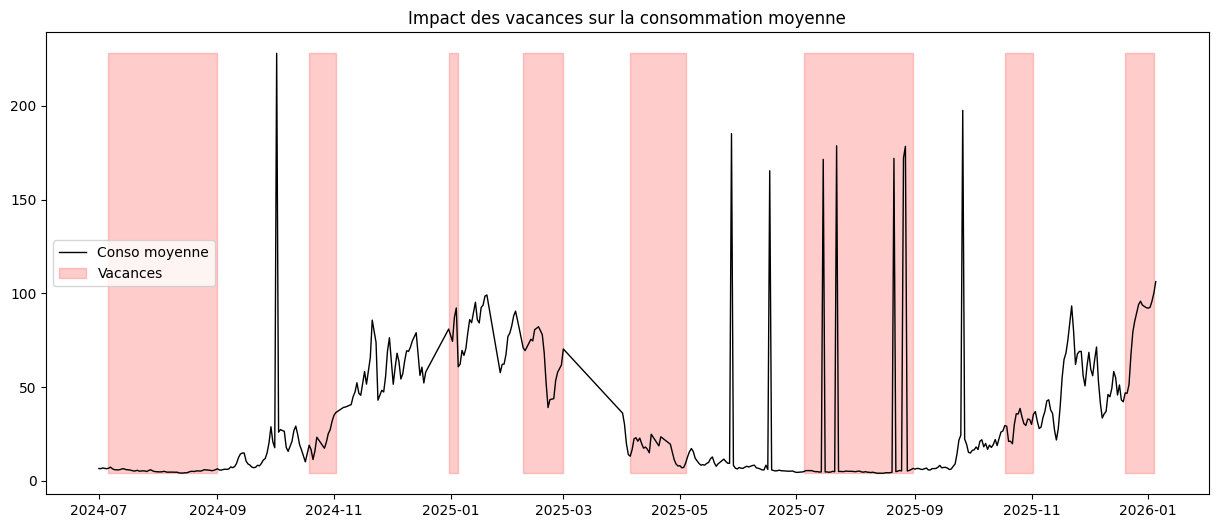

In [69]:
# 1. On prépare les données agrégées par jour
# On calcule la moyenne de conso pour que le graphique ne soit pas pollué par le nombre de compteurs
daily_stats = df.groupby('date_parsed').agg({
    'valeur_energie_conso': 'mean',
    'is_school_holiday': 'max'
}).reset_index()

# 2. On trace la courbe
plt.figure(figsize=(15, 6))
plt.plot(daily_stats['date_parsed'], daily_stats['valeur_energie_conso'], color='black', lw=1, label='Conso moyenne')

# 3. On colorie les zones de vacances
# On utilise fill_between pour créer des blocs propres
plt.fill_between(daily_stats['date_parsed'], 
                 daily_stats['valeur_energie_conso'].min(), 
                 daily_stats['valeur_energie_conso'].max(), 
                 where=(daily_stats['is_school_holiday'] == 1),
                 color='red', alpha=0.2, label='Vacances')

plt.title("Impact des vacances sur la consommation moyenne")
plt.legend()
plt.show()

Nettoyage des outliers (méthode IQR)

In [ ]:
df['temp_scaled'] = (df['temperature'] - df['temperature'].mean()) / df['temperature'].std()

print("Entraînement du modèle LMM")

# Entrainement du modèle sur la simple valeur température
model_lmm = smf.mixedlm("valeur_energie_conso ~ temp_scaled", 
                        data=df, 
                        groups=df['pce'], 
                        re_formula="~temp_scaled")

# Stockage des résidus
result_lmm = model_lmm.fit(method=["lbfgs"]) 
print("Entraînement terminé !")

fixed_intercept = result_lmm.params['Intercept']
fixed_slope = result_lmm.params['temp_scaled']

re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')

re_df = re_df.rename(columns={'temp_scaled': 'rand_slope'})
col_intercept = [c for c in re_df.columns if c != 'rand_slope'][0] # On trouve l'autre colonne dynamiquement
re_df = re_df.rename(columns={col_intercept: 'rand_intercept'})

re_df.index.name = 'pce'

df = df.merge(re_df, on='pce', how='left')

df['intercept_client'] = fixed_intercept + df['rand_intercept']
df['pente_client'] = fixed_slope + df['rand_slope']

# Prédiction propre au client et calcul du résidu "pur" (sans l'effet météo)
df['conso_predite'] = df['intercept_client'] + (df['pente_client'] * df['temp_scaled'])
df['conso_residu'] = df['valeur_energie_conso'] - df['conso_predite']

# Nettoyage des outliers par IQR
def remove_outliers_iqr(group):
    # L'analyse se fait uniquement sur le résidu, propre à chaque compteur
    Q1 = group['conso_residu'].quantile(0.25)
    Q3 = group['conso_residu'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # On filtre les lignes où le résidu est dans les bornes (comportement normal)
    return group[(group['conso_residu'] >= lower_bound) & (group['conso_residu'] <= upper_bound)]

print("Filtrage des valeurs aberrantes (Outliers) par PCE...")
# Application du filtre (compatible avec les versions Pandas < 2.2.0)
df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)

# On supprime toutes les colonnes intermédiaires de calcul pour garder un dataframe propre
cols_to_drop = ['temp_scaled', 'rand_intercept', 'rand_slope', 'intercept_client', 
                'pente_client', 'conso_predite', 'conso_residu']
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

# Si vous aviez une colonne 'year', on filtre pour ne garder que les compteurs présents sur >1 an
if 'year' in df_clean.columns:
    pce_counts = df_clean.groupby('pce')['year'].nunique()
    consistent_pce = pce_counts[pce_counts >= 2].index
    df_final = df_clean[df_clean['pce'].isin(consistent_pce)]
else:
    df_final = df_clean.copy()

print(f"Terminé ! Nombre de lignes restantes : {len(df_final)}")

Entraînement du modèle LMM en cours (cela peut prendre un peu de temps)...


C:\Users\utilisateur\AppData\Roaming\Python\Python313\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


Entraînement terminé !
Filtrage des valeurs aberrantes (Outliers) par PCE...


C:\Users\utilisateur\AppData\Local\Temp\ipykernel_18352\3111119416.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)


Terminé ! Nombre de lignes restantes : 2667525


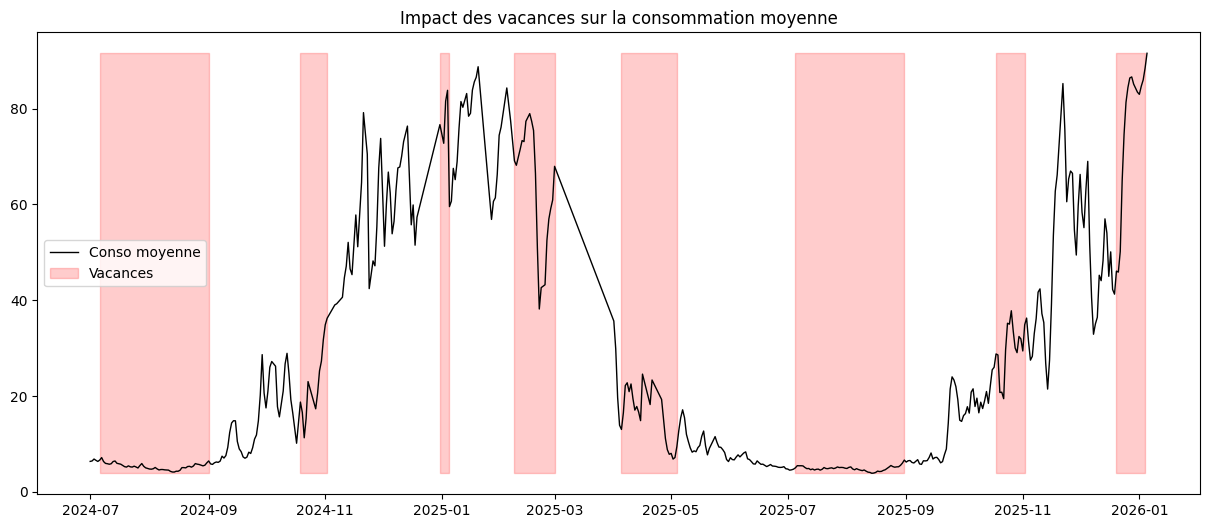

In [73]:
# 1. On prépare les données agrégées par jour
# On calcule la moyenne de conso pour que le graphique ne soit pas pollué par le nombre de compteurs
daily_stats = df_final.groupby('date_parsed').agg({
    'valeur_energie_conso': 'mean',
    'is_school_holiday': 'max'
}).reset_index()

# 2. On trace la courbe
plt.figure(figsize=(15, 6))
plt.plot(daily_stats['date_parsed'], daily_stats['valeur_energie_conso'], color='black', lw=1, label='Conso moyenne')

# 3. On colorie les zones de vacances
# On utilise fill_between pour créer des blocs propres
plt.fill_between(daily_stats['date_parsed'], 
                 daily_stats['valeur_energie_conso'].min(), 
                 daily_stats['valeur_energie_conso'].max(), 
                 where=(daily_stats['is_school_holiday'] == 1),
                 color='red', alpha=0.2, label='Vacances')

plt.title("Impact des vacances sur la consommation moyenne")
plt.legend()
plt.show()

Application de LMM

In [75]:
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# On repart du dataframe
df_lmm = df_final.copy()

# Saisonnalité

# Saisonnalité Annuelle / Mensuelle (Période = 365.25 jours)
df_lmm['day_of_year'] = df_lmm['date_parsed'].dt.dayofyear
df_lmm['sin_month'] = np.sin(2 * np.pi * df_lmm['day_of_year'] / 365.25)
df_lmm['cos_month'] = np.cos(2 * np.pi * df_lmm['day_of_year'] / 365.25)

# Saisonnalité Hebdomadaire (Période = 7 jours)
df_lmm['day_of_week'] = df_lmm['date_parsed'].dt.dayofweek
df_lmm['sin_week'] = np.sin(2 * np.pi * df_lmm['day_of_week'] / 7)
df_lmm['cos_week'] = np.cos(2 * np.pi * df_lmm['day_of_week'] / 7)


# 3. Régression
formula = "valeur_energie_conso ~ hdd + trend + is_school_holiday + sin_month + cos_month + sin_week + cos_week"

print("Démarrage du modèle LMM...")
        
# re_formula="~hdd" : Pente aléatoire pour le HDD brut
model_lmm = smf.mixedlm(formula, data=df_lmm, groups=df_lmm["pce"], re_formula="~hdd")

# method=["lbfgs"] est plus robuste pour converger
result_lmm = model_lmm.fit(method=["lbfgs"], maxiter=600)

Démarrage du modèle LMM...


Résultats du LMM

In [79]:
# Résultats du modèle
print(result_lmm.summary())
        
# Effets aléatoires:
print("Exemple d'Effets Aléatoire:")
print(pd.DataFrame(result_lmm.random_effects).T.head(5))

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valeur_energie_conso
No. Observations: 2667525 Method:             REML                
No. Groups:       7368    Scale:              145.3004            
Min. group size:  4       Log-Likelihood:     -10466820.7395      
Max. group size:  473     Converged:          Yes                 
Mean group size:  362.0                                           
-------------------------------------------------------------------
                   Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
-------------------------------------------------------------------
Intercept          11.125     0.096  115.392  0.000  10.936  11.314
hdd                 4.695     0.044  106.394  0.000   4.608   4.781
trend              -0.002     0.000  -40.437  0.000  -0.002  -0.002
is_school_holiday  -0.177     0.016  -11.324  0.000  -0.207  -0.146
sin_month           2.237     0.013  166.112  0.000   2.211   2.263
co

Stockage des résultats dans "df_results"

In [80]:
# Extraction des Effets Fixes (Population globale)
beta_hdd_fixed = result_lmm.params['hdd']

# Extraction des Effets Aléatoires (Spécifiques par client): le dico result_lmm.random_effects contient les écarts pour chaque PCE
re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
re_df = re_df.rename(columns={'hdd': 'hdd_random_slope', 'Group': 'intercept_random'})
re_df.index.name = 'pce'

# Fusion avec les données d'origine utilisées dans le modèle
df_results = df_lmm.copy()
df_results = df_results.merge(re_df, on='pce', how='left')

# Calcul de la pente totale : Pente Client = Pente Moyenne (Fixed) + Écart Client (Random)
df_results['total_hdd_slope'] = beta_hdd_fixed + df_results['hdd_random_slope']

# Calcul de la Consommation Normalisée (On retire l'effet météo spécifique à ce client pour ne garder que le comportement : Conso_Norm = Conso_Reelle - (Sensibilité_Client * Météo)
df_results['conso_norm'] = df_results['valeur_energie_conso'] - (df_results['total_hdd_slope'] * df_results['hdd'])

Evolution d'une années sur l'autre (pb car ici juste 1 an)

In [81]:
# Agrégation Mensuelle : On fait la moyenne des consos normalisées par mois
summary_lmm = df_results.groupby(['year', 'month'])['conso_norm'].mean().reset_index()

# Pivot pour comparer les années (2025 vs 2024)
pivot_lmm = summary_lmm.pivot(index='month', columns='year', values='conso_norm')

# Calcul de l'évolution
if 2024 in pivot_lmm.columns and 2025 in pivot_lmm.columns:
    pivot_lmm['Evolution_2025_vs_2024 (%)'] = ((pivot_lmm[2025] - pivot_lmm[2024]) / pivot_lmm[2024]) * 100
    
    print("\n RÉSULTATS FINAUX ")
    print("Évolution de la consommation corrigée du climat (Demand Destruction) :")
    print(pivot_lmm[['Evolution_2025_vs_2024 (%)']].round(2))
    
    avg_drop = pivot_lmm['Evolution_2025_vs_2024 (%)'].mean()
    print(f"\n>> Moyenne globale de la baisse sur la période : {avg_drop:.2f}%")
else:
    print("Pas assez de données communes pour comparer les années.")


 RÉSULTATS FINAUX 
Évolution de la consommation corrigée du climat (Demand Destruction) :
year   Evolution_2025_vs_2024 (%)
month                            
1                             NaN
2                             NaN
3                             NaN
4                             NaN
5                             NaN
6                             NaN
7                          -15.34
8                           -3.43
9                            2.20
10                           9.28
11                          -6.42
12                         -16.36

>> Moyenne globale de la baisse sur la période : -5.01%


Réprésentation graphique des résultats
- 1 : Scatter plot pour individus
- 2 : Evolution de la conso sans l'effet météo

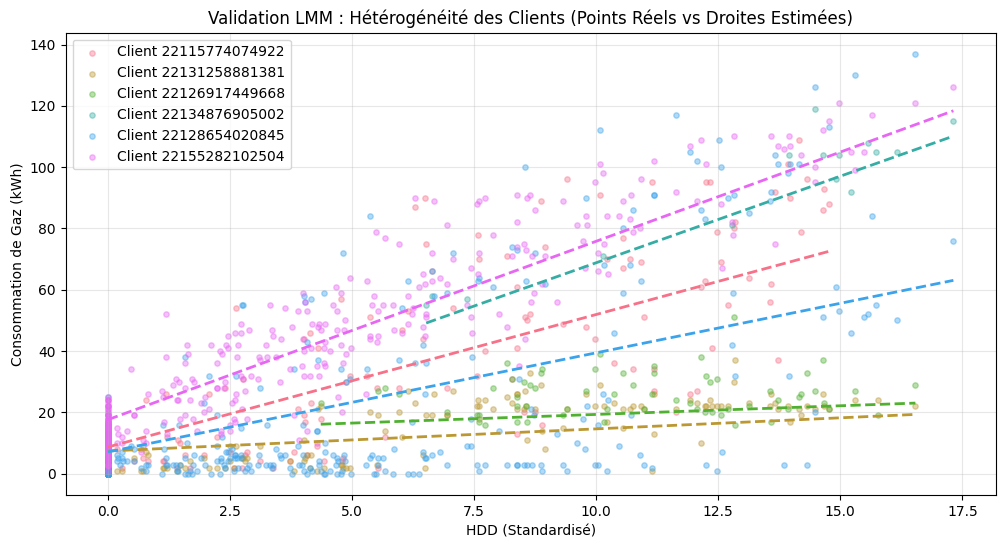

In [82]:
# Objectif : Montrer que chaque client réagit différemment au froid (Pentes aléatoires)

# Sélection de 6 clients aléatoires
sample_pces = np.random.choice(df_results['pce'].unique(), 6, replace=False)
subset_plot = df_results[df_results['pce'].isin(sample_pces)].copy()

plt.figure(figsize=(12, 6))

# Palette de couleurs pour distinguer les clients
colors = sns.color_palette("husl", len(sample_pces))

for i, pce in enumerate(sample_pces):
    pce_data = subset_plot[subset_plot['pce'] == pce]
    color = colors[i]
    
    # Nuage de points
    plt.scatter(pce_data['hdd'], pce_data['valeur_energie_conso'], 
                alpha=0.4, s=15, color=color, label=f"Client {pce}")
    
    # Droite du Modèle LMM (Pente spécifique à ce client)
    # y = (Intercept_Fixe + Intercept_Random) + (Pente_Fixe + Pente_Random) * X
    intercept_fixed = result_lmm.params['Intercept']
    intercept_total = intercept_fixed + pce_data['intercept_random'].iloc[0]
    slope_total = pce_data['total_hdd_slope'].iloc[0]
    
    # Création de la ligne de régression
    x_vals = np.array([pce_data['hdd'].min(), pce_data['hdd'].max()])
    y_vals = intercept_total + slope_total * x_vals
    
    plt.plot(x_vals, y_vals, color=color, linewidth=2, linestyle='--')

plt.title("Validation LMM : Hétérogénéité des Clients (Points Réels vs Droites Estimées)")
plt.xlabel("HDD (Standardisé)")
plt.ylabel("Consommation de Gaz (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

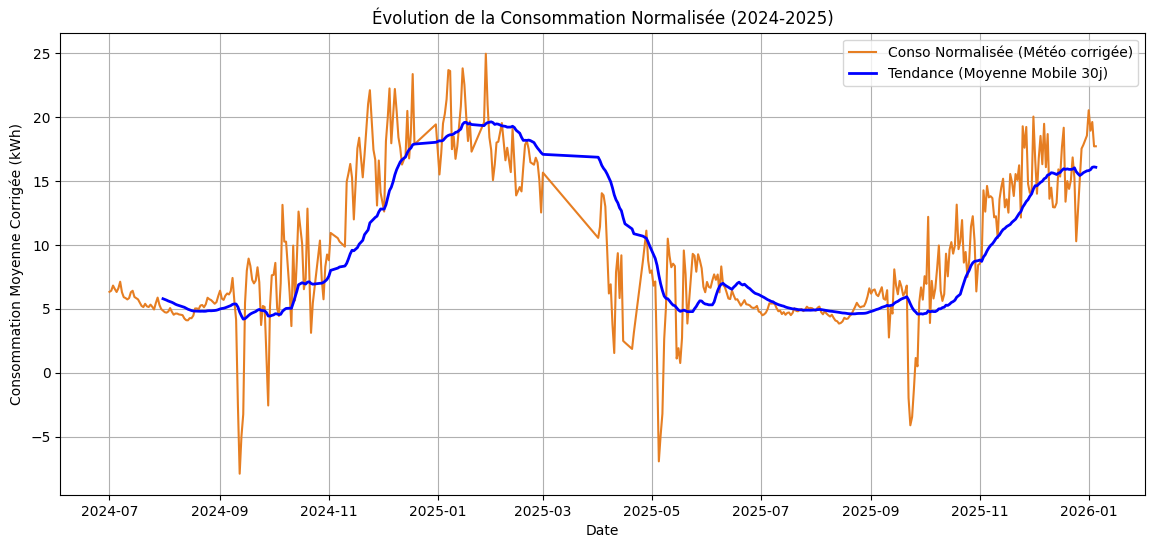

In [83]:
# Objectif : Voir la courbe de consommation "nettoyée" de la météo
plt.figure(figsize=(14, 6))

# On agrège par jour pour alléger le graphique
daily_trend = df_results.groupby('date_parsed')['conso_norm'].mean()

# Tracé de la courbe
plt.plot(daily_trend.index, daily_trend.values, color='#e67e22', linewidth=1.5, label='Conso Normalisée (Météo corrigée)')

# Ajout d'une moyenne mobile pour voir la tendance de fond (Trend)
plt.plot(daily_trend.rolling(window=30).mean().index, 
         daily_trend.rolling(window=30).mean().values, 
         color='blue', linewidth=2, linestyle='-', label='Tendance (Moyenne Mobile 30j)')

plt.title("Évolution de la Consommation Normalisée (2024-2025)")
plt.ylabel("Consommation Moyenne Corrigée (kWh)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()